# Lab CNN — 04: Ajuste de hiperparámetros

Se entrena la misma arquitectura base con **tres configuraciones** que varían número de
filtros, tamaño del kernel, tasa de aprendizaje y tasa de dropout, y se comparan sus
métricas de validación y prueba.

| Config | Filtros | Kernel | LR | Dropout | Variación |
|--------|---------|--------|-----|---------|----------|
| Baseline | [32, 64, 128] | 3×3 | 1e-3 | 0.5 | referencia (mismo que Ex3) |
| Config A | [32, 64, 128] | 3×3 | 5e-4 | 0.3 | LR más baja + menos dropout |
| Config B | [16, 32, 64] | 5×5 | 1e-3 | 0.5 | menos filtros + kernel mayor |

> **Nota de memoria:** la GTX 1650 tiene 2 GB de VRAM. Entre experimentos se llama
> `tf.keras.backend.clear_session()` + `gc.collect()` para liberar la GPU antes
> de construir el siguiente modelo.

## 0. Imports, rutas y carga de datos

In [1]:
import gc
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

BASE_DIR   = Path().resolve().parent
OUT_DIR    = BASE_DIR / "outputs"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

DATA_PATH  = OUT_DIR / "data_splits.npz"
MODEL_PATH = MODELS_DIR / "model.keras"

IMG_SHAPE  = (128, 128, 3)
BATCH_SIZE = 32
EPOCHS     = 25

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU')}")

2026-05-05 19:53:18.860925: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 19:53:19.637810: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


2026-05-05 19:53:21.123991: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/valentinau/miniconda3/envs/labcnn/lib:/usr/lib/wsl/lib
2026-05-05 19:53:21.124364: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /home/valentinau/miniconda3/envs/labcnn/lib:/usr/lib/wsl/lib
2026-05-05 19:53:21.124377: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Cannot dlopen some TensorRT libraries. If you would like to use Nvidia GPU with TensorRT, please make sure the missing libraries mentioned above are installed properly.


TensorFlow : 2.10.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-05-05 19:53:23.822637: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 19:53:23.894237: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 19:53:23.894305: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
data = np.load(str(DATA_PATH))
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
print(f"Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}")

Train: (3792, 128, 128, 3)  Val: (813, 128, 128, 3)  Test: (813, 128, 128, 3)


## 1. Definición de configuraciones y funciones auxiliares

`build_model` construye la CNN parametrizando filtros, tamaño de kernel y dropout.
`run_experiment` entrena una configuración, guarda el modelo en disco, libera la
GPU y devuelve sólo métricas numéricas.

In [3]:
CONFIGS = {
    "Baseline": {"filters": [32, 64, 128], "kernel": 3, "lr": 1e-3, "dropout": 0.5},
    "Config A": {"filters": [32, 64, 128], "kernel": 3, "lr": 5e-4, "dropout": 0.3},
    "Config B": {"filters": [16, 32,  64], "kernel": 5, "lr": 1e-3, "dropout": 0.5},
}

In [4]:
def build_model(filters, kernel, dropout, img_shape=IMG_SHAPE):
    return Sequential([
        Conv2D(filters[0], (kernel, kernel), activation="relu", padding="same", input_shape=img_shape),
        MaxPooling2D((2, 2)),
        Conv2D(filters[1], (kernel, kernel), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Conv2D(filters[2], (kernel, kernel), activation="relu", padding="same"),
        MaxPooling2D((2, 2)),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(dropout),
        Dense(1, activation="sigmoid"),
    ])


def run_experiment(name, cfg):
    # Liberar GPU antes de construir el nuevo modelo
    tf.keras.backend.clear_session()
    gc.collect()

    print(f"\n{'='*55}")
    print(f"  {name}: filtros={cfg['filters']}  kernel={cfg['kernel']}x{cfg['kernel']}  "
          f"lr={cfg['lr']}  dropout={cfg['dropout']}")
    print(f"{'='*55}")

    model = build_model(cfg["filters"], cfg["kernel"], cfg["dropout"])
    model.compile(
        optimizer=Adam(learning_rate=cfg["lr"]),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    n_params = model.count_params()
    print(f"  Parámetros totales: {n_params:,}")

    # Guardar en disco para no acumular modelos en VRAM
    tmp_path = MODELS_DIR / f"tmp_{name.replace(' ', '_')}.keras"

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
        ModelCheckpoint(filepath=str(tmp_path), monitor="val_loss", save_best_only=True, verbose=0),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=0,
    )

    test_loss, test_acc = model.evaluate(X_test, y_test, batch_size=BATCH_SIZE, verbose=0)

    # Serializar historial a dicts puros (float) y liberar objetos Keras
    hist = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    del model, history
    gc.collect()

    best_val_acc  = max(hist["val_accuracy"])
    best_val_loss = min(hist["val_loss"])
    epochs_run    = len(hist["loss"])

    print(f"  Épocas ejecutadas : {epochs_run}")
    print(f"  Mejor val_acc     : {best_val_acc:.4f}")
    print(f"  Test accuracy     : {test_acc:.4f}")

    return {
        "history":       hist,
        "test_loss":     float(test_loss),
        "test_acc":      float(test_acc),
        "best_val_acc":  best_val_acc,
        "best_val_loss": best_val_loss,
        "epochs_run":    epochs_run,
        "params":        n_params,
        "tmp_path":      tmp_path,
    }

## 2. Ejecución de experimentos

Se entrena cada configuración de forma secuencial usando los mismos splits y semilla.
El modelo de cada experimento se guarda en disco y se libera de la GPU antes de
iniciar el siguiente.

In [5]:
results = {}
for name, cfg in CONFIGS.items():
    results[name] = run_experiment(name, cfg)

print("\nTodos los experimentos completados.")


  Baseline: filtros=[32, 64, 128]  kernel=3x3  lr=0.001  dropout=0.5


2026-05-05 19:53:27.640737: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-05 19:53:27.641991: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 19:53:27.642066: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-05 19:53:27.642110: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:966] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built witho

  Parámetros totales: 4,287,809


2026-05-05 19:53:29.756013: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 745537536 exceeds 10% of free system memory.
2026-05-05 19:53:30.525233: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 745537536 exceeds 10% of free system memory.


2026-05-05 19:53:33.189298: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8100


...

  Épocas ejecutadas : 14
  Mejor val_acc     : 0.9926
  Test accuracy     : 0.9852

  Config B: filtros=[16, 32, 64]  kernel=5x5  lr=0.001  dropout=0.5
  Parámetros totales: 2,162,721


2026-05-05 19:55:44.948266: W tensorflow/core/framework/cpu_allocator_impl.cc:82] Allocation of 745537536 exceeds 10% of free system memory.


Restoring model weights from the end of the best epoch: 9.


Epoch 15: early stopping


  Épocas ejecutadas : 15
  Mejor val_acc     : 0.9889
  Test accuracy     : 0.9729

Todos los experimentos completados.


## 3. Comparación de resultados

In [6]:
print(f"{'Config':<12} {'Filtros':>18} {'Kernel':>8} {'LR':>8} {'Drop':>6} "
      f"{'Params':>10} {'Épocas':>7} {'val_acc':>9} {'test_acc':>10}")
print("-" * 100)

for name, cfg in CONFIGS.items():
    r = results[name]
    print(f"{name:<12} {str(cfg['filters']):>18} {cfg['kernel']:>6}x{cfg['kernel']:<1} {cfg['lr']:>8.4f} "
          f"{cfg['dropout']:>6.1f} {r['params']:>10,} {r['epochs_run']:>7} "
          f"{r['best_val_acc']:>9.4f} {r['test_acc']:>10.4f}")

best_name = max(results, key=lambda k: results[k]["test_acc"])
print(f"\nMejor configuración por test_acc: {best_name} ({results[best_name]['test_acc']:.4f})")

Config                  Filtros   Kernel       LR   Drop     Params  Épocas   val_acc   test_acc
----------------------------------------------------------------------------------------------------
Baseline          [32, 64, 128]      3x3   0.0010    0.5  4,287,809      17    0.9877     0.9852
Config A          [32, 64, 128]      3x3   0.0005    0.3  4,287,809      14    0.9926     0.9852
Config B           [16, 32, 64]      5x5   0.0010    0.5  2,162,721      15    0.9889     0.9729

Mejor configuración por test_acc: Baseline (0.9852)


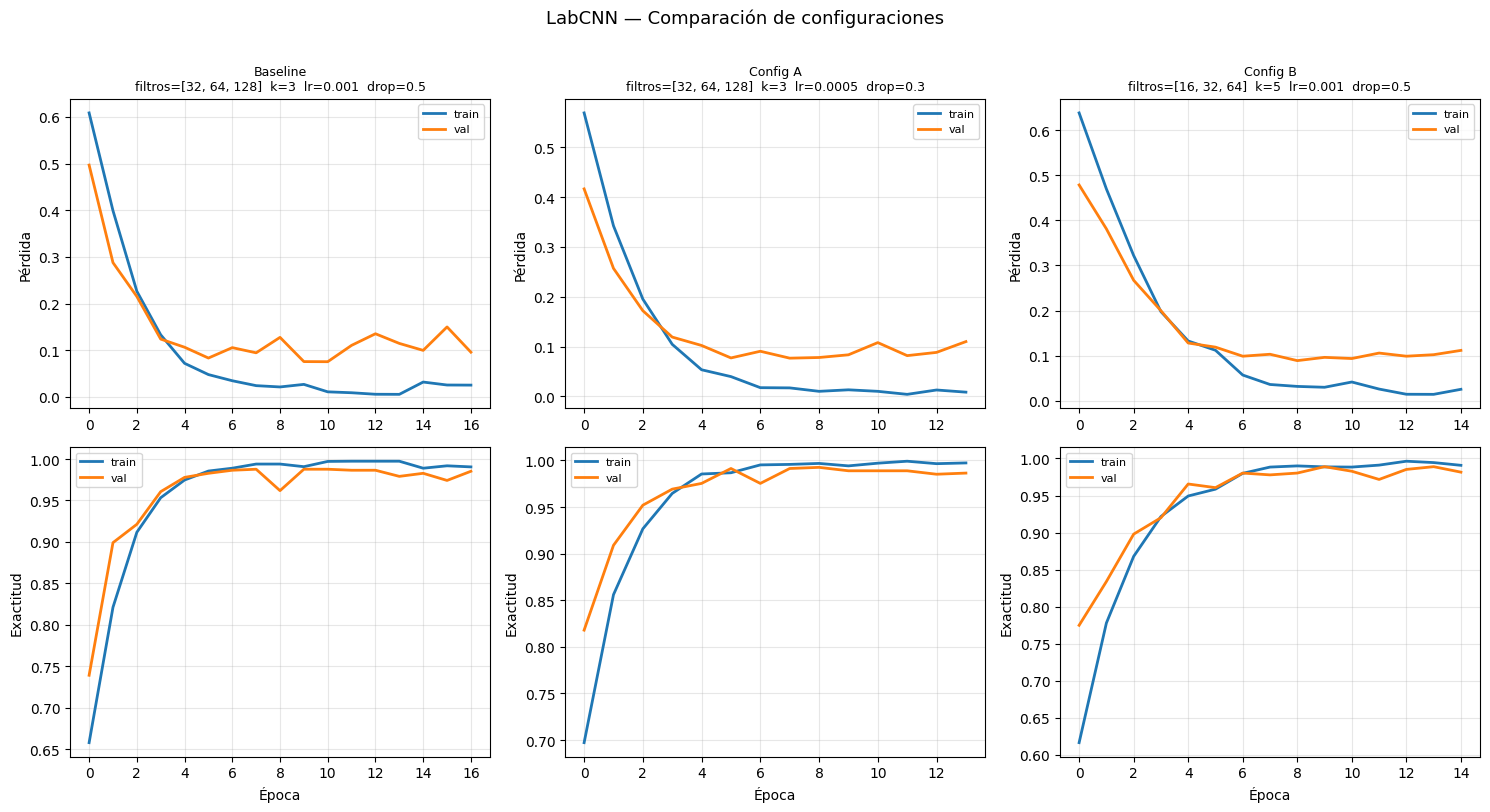

Curvas guardadas en: outputs/comparacion_configs.png


In [7]:
fig, axes = plt.subplots(2, len(CONFIGS), figsize=(5 * len(CONFIGS), 8))

for col, (name, r) in enumerate(results.items()):
    hist = r["history"]   # ya es un dict de listas
    cfg  = CONFIGS[name]
    title = (f"{name}\nfiltros={cfg['filters']}  k={cfg['kernel']}  "
             f"lr={cfg['lr']}  drop={cfg['dropout']}")

    axes[0, col].plot(hist["loss"],     label="train", linewidth=2)
    axes[0, col].plot(hist["val_loss"], label="val",   linewidth=2)
    axes[0, col].set_title(title, fontsize=9)
    axes[0, col].set_ylabel("Pérdida")
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(True, alpha=0.3)

    axes[1, col].plot(hist["accuracy"],     label="train", linewidth=2)
    axes[1, col].plot(hist["val_accuracy"], label="val",   linewidth=2)
    axes[1, col].set_ylabel("Exactitud")
    axes[1, col].set_xlabel("Época")
    axes[1, col].legend(fontsize=8)
    axes[1, col].grid(True, alpha=0.3)

plt.suptitle("LabCNN — Comparación de configuraciones", fontsize=13, y=1.01)
plt.tight_layout()
plot_path = OUT_DIR / "comparacion_configs.png"
fig.savefig(str(plot_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Curvas guardadas en: {plot_path.relative_to(BASE_DIR)}")

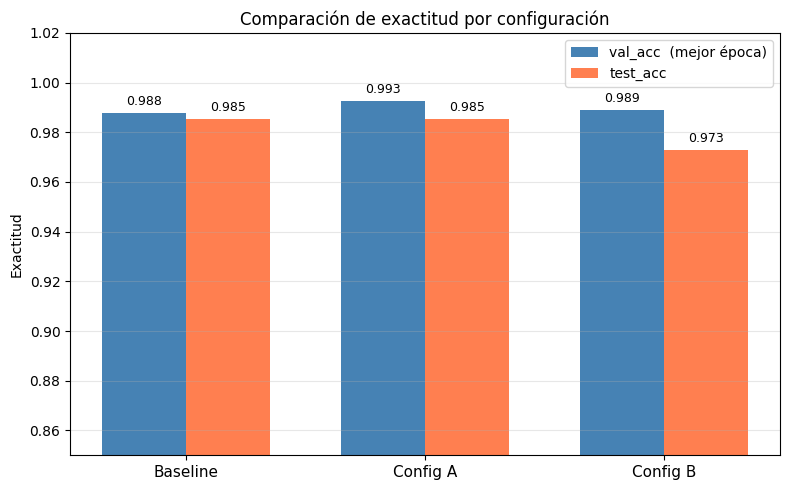

Gráfico guardado en: outputs/comparacion_barras.png


In [8]:
names     = list(results.keys())
val_accs  = [results[n]["best_val_acc"] for n in names]
test_accs = [results[n]["test_acc"]     for n in names]

x = np.arange(len(names))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - w/2, val_accs,  w, label="val_acc  (mejor época)", color="steelblue")
bars2 = ax.bar(x + w/2, test_accs, w, label="test_acc",               color="coral")

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel("Exactitud")
ax.set_title("Comparación de exactitud por configuración")
ax.set_ylim(0.85, 1.02)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
bar_path = OUT_DIR / "comparacion_barras.png"
fig.savefig(str(bar_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"Gráfico guardado en: {bar_path.relative_to(BASE_DIR)}")

## 4. Conclusiones y guardado del mejor modelo

Si la mejor configuración de este experimento supera al modelo de Ex3,
se carga desde disco y se sobreescribe `models/model.keras`.
Se eliminan los archivos temporales de los otros experimentos.

In [9]:
print("RESUMEN DE EXPERIMENTOS")
print("=" * 55)
for name, r in results.items():
    delta = r["test_acc"] - results["Baseline"]["test_acc"]
    sign  = "+" if delta >= 0 else ""
    print(f"  {name:<12}  test_acc={r['test_acc']:.4f}  "
          f"Δbaseline={sign}{delta:.4f}  épocas={r['epochs_run']}")

best_name = max(results, key=lambda k: results[k]["test_acc"])
best_acc  = results[best_name]["test_acc"]
print(f"\nMejor configuración: {best_name}  (test_acc={best_acc:.4f})")

ex3_acc = 0.9643
if best_acc > ex3_acc:
    tf.keras.backend.clear_session()
    best_model = tf.keras.models.load_model(str(results[best_name]["tmp_path"]))
    best_model.save(str(MODEL_PATH))
    del best_model
    gc.collect()
    print(f"Modelo actualizado en {MODEL_PATH.relative_to(BASE_DIR)} "
          f"({best_acc:.4f} > ex3={ex3_acc:.4f})")
else:
    print(f"Se conserva el modelo de Ex3 (ex3={ex3_acc:.4f} >= mejor aquí={best_acc:.4f})")

# Limpiar archivos temporales
for r in results.values():
    if r["tmp_path"].exists():
        r["tmp_path"].unlink()
print("Archivos temporales eliminados.")

RESUMEN DE EXPERIMENTOS
  Baseline      test_acc=0.9852  Δbaseline=+0.0000  épocas=17
  Config A      test_acc=0.9852  Δbaseline=+0.0000  épocas=14
  Config B      test_acc=0.9729  Δbaseline=-0.0123  épocas=15

Mejor configuración: Baseline  (test_acc=0.9852)


Modelo actualizado en models/model.keras (0.9852 > ex3=0.9643)
Archivos temporales eliminados.
